# Hackathon 3 · Una neurona aprende AND

**Documento principal · Trabajo en parejas · 90 minutos orientativos**

Vas a completar e interpretar el entrenamiento de una neurona que recibe dos entradas,
cada una igual a 0 o 1. Debe responder 1 únicamente cuando ambas entradas son 1.
Trabajaremos primero con un ejemplo resuelto, luego con una práctica breve y finalmente
con los cuatro ejemplos de AND.

El motor de autodiferenciación, la sigmoide, la pérdida, las tablas y las gráficas ya están
implementados. **No debes derivar la sigmoide ni la pérdida, ni construir el motor.**
Completarás tres funciones cortas y explicarás resultados observables.

En cada etapa: **lee → predice → completa → ejecuta → contrasta → explica**.
Una predicción razonada puede ser incorrecta. Consérvala y explica después qué aprendiste;
no la reemplaces para que parezca correcta desde el inicio.

**Integrantes**

1. Roberth Chachalo
2. Jaime Astudillo

## Cómo trabajar

- Lee cada explicación antes de ejecutar la siguiente celda. Usa `Shift + Enter`.
- Modifica solamente las celdas de respuestas, los nombres y las tres funciones con espacios por completar.
- En esas funciones, sustituye `...` por tu código. No cambies los nombres de las funciones ni sus argumentos.
- Los mensajes **PENDIENTE** son normales al abrir el notebook. No ejecutan una solución sustituta.
  Las etapas que dependen de una función pendiente esperan a que la completes.
- Si aparece un error de comprobación, lee su mensaje, vuelve a la función y ejecútala otra vez.
  Para repetir una práctica, ejecuta también su celda de preparación: así empieza desde el mismo estado.
- Una persona escribe y otra verifica. Intercambien roles antes de la etapa 4.
  Escriban las predicciones individualmente en sus notas y acuerden después la respuesta del equipo.
- Los apoyos desplegables son parte de la actividad: pueden consultarlos.
- Antes de la clase debe estar instalado el entorno. No se necesita red ni GPU durante el trabajo.

| Etapa | Actividad | Minutos orientativos |
|---|---|---:|
| 0 | Entender AND y reconocer los objetos | 8 |
| 1 | Seguir un ejemplo completamente resuelto | 15 |
| 2 | Completar la predicción y leer gradientes | 12 |
| 3 | Completar y explicar una actualización | 15 |
| 4 | Integrar el ciclo y entrenar | 20 |
| 5 | Interpretar la tabla final y los límites | 15 |
| 6 | Verificar y entregar | 5 |

In [1]:
import os
from pathlib import Path
from and_lab import (
    Value, ActividadPendiente, DATOS_AND, TASA, ITERACIONES,
    crear_parametros, valores, gradientes, reiniciar_gradientes,
    sigmoide, perdida_binaria, perdida_lote, forward_resuelto,
    tabla, tabla_parametros, inspeccionar_grafo, dibujar_grafo,
    comprobar_forward, comprobar_actualizacion, comprobar_paso,
    entrenar, evaluar, guardar_resultados, validar_final,
)

OUTPUT_DIR = Path(os.environ.get("H3_OUTPUT_DIR", "output"))
estado = {"forward": False, "actualizacion": False, "ciclo": False}
historial = []
parametros_entrenados = None
print("Entorno preparado. Todas las operaciones se realizan localmente en CPU.")

Entorno preparado. Todas las operaciones se realizan localmente en CPU.


## Etapa 0 · Qué significa aprender AND

Piensa en un dispositivo que se activa solo cuando **dos permisos** están presentes.
Cada entrada vale 1 si hay permiso y 0 si no lo hay. Esta tabla contiene todos los casos posibles:

| Entrada $x_1$ | Entrada $x_2$ | Objetivo $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

La neurona combina las entradas y después aplica una función proporcionada:

$$z=w_1x_1+w_2x_2+b,\qquad \hat y=\operatorname{sigmoide}(z).$$

Lectura: multiplica cada entrada por su peso, suma ambos productos y agrega el sesgo.
La sigmoide convierte ese resultado en una probabilidad entre 0 y 1.
Por ejemplo, sigmoide(0) = 0.5; aumentar $z$ aumenta esa probabilidad.

| Objeto | Significado | ¿Se actualiza durante el entrenamiento? |
|---|---|---|
| `x1`, `x2` | Entradas de un ejemplo | No |
| `y` | Respuesta correcta | No |
| `w1`, `w2` | Pesos de las entradas | Sí |
| `b` | Sesgo, sumado incluso cuando las entradas son cero | Sí |
| `z`, probabilidad, `L` | Resultados calculados en el forward | Se calculan de nuevo |

Un parámetro `Value` tiene `.data` (su valor actual) y `.grad` (su gradiente almacenado).
**No son lo mismo.** El motor también registra dependencias entre objetos.
Las hojas no son necesariamente parámetros: el grafo puede contener datos y constantes como hojas.
Nosotros solo actualizaremos los tres objetos de `parametros`.

La función `perdida_binaria(probabilidad, objetivo)` ya está escrita. Devuelve un escalar:
una probabilidad más próxima al objetivo produce menor pérdida. Para probabilidad 0.5,
la pérdida es aproximadamente 0.693147, tanto con objetivo 0 como con objetivo 1.

Durante el entrenamiento usamos probabilidades, **no redondeamos**. Solo al evaluar
convertimos a clase: probabilidad mayor o igual a 0.5 → 1; menor que 0.5 → 0.

**R1 · Reconocimiento. ¿Cuándo debe activarse el dispositivo y cuáles son los tres objetos que ajustará el entrenamiento?**

El dispositivo se activa (objetivo 1) únicamente en el caso (1, 1), es decir, cuando ambos permisos están presentes al mismo tiempo; en (0, 0), (0, 1) y (1, 0) el objetivo es 0. Los tres objetos que el entrenamiento ajusta son los dos pesos `w1` y `w2` y el sesgo `b`. Las entradas `x1`, `x2` y el objetivo `y` son datos fijos y no se actualizan, mientras que `z`, la probabilidad y la pérdida `L` no se ajustan sino que se vuelven a calcular en cada forward.

## Etapa 1 · Ejemplo completamente resuelto

Observaremos **solo (1, 1) con objetivo 1**, con los tres parámetros inicialmente en cero.
Este ejemplo permite seguir un paso; aún no demuestra que la neurona aprendió AND.

Primero: $z=0\times1+0\times1+0=0$; por tanto, $\hat y=0.5$.
La salida está por debajo del objetivo 1. El siguiente código ya está completo.

In [2]:
parametros_demo = crear_parametros()  # tres hojas nuevas con valor cero
p_demo = forward_resuelto(1, 1, parametros_demo)
L_demo = perdida_binaria(p_demo, 1)
print(f"Probabilidad: {p_demo.data:.6f} | Pérdida: {L_demo.data:.6f}")
tabla_parametros(parametros_demo, "Después del forward y antes de backward")

Probabilidad: 0.500000 | Pérdida: 0.693147


parámetro,valor,gradiente
w1,0.000000,0.000000
w2,0.000000,0.000000
b,0.000000,0.000000


Ahora `L_demo.backward()` recorre las dependencias en sentido inverso y calcula
cómo cambia la pérdida al variar cada parámetro. **No actualiza los parámetros.**

El motor comienza con gradiente 1 en la pérdida. Para este ejemplo obtendrás
gradientes $-0.5$ en los tres parámetros. El signo negativo indica que un pequeño
aumento de cada parámetro, manteniendo los otros fijos, reduce localmente la pérdida.

In [3]:
valores_antes_backward = valores(parametros_demo)
L_demo.backward()
tabla_parametros(parametros_demo, "Después de backward")
assert valores(parametros_demo) == valores_antes_backward
print("Comprobación: backward cambió .grad, pero conservó .data.")

parámetro,valor,gradiente
w1,0.000000,-0.500000
w2,0.000000,-0.500000
b,0.000000,-0.500000


Comprobación: backward cambió .grad, pero conservó .data.


### Cómo leer el grafo proporcionado

Las flechas siguen el forward, desde los datos y parámetros hasta la pérdida.
Backward recorre el grafo al revés. Cada nodo muestra su valor y su gradiente
respecto de esta pérdida. Los gradientes de datos o constantes que muestra este
motor son sensibilidades, no una instrucción para entrenarlos.

Busca primero **w1, w2, b, z, probabilidad y pérdida**. Sigmoide y BCE son operaciones
proporcionadas: no desplegamos sus cálculos internos ni debes derivarlas.
La tabla posterior enumera todos los nodos de esta ejecución y sus conexiones.

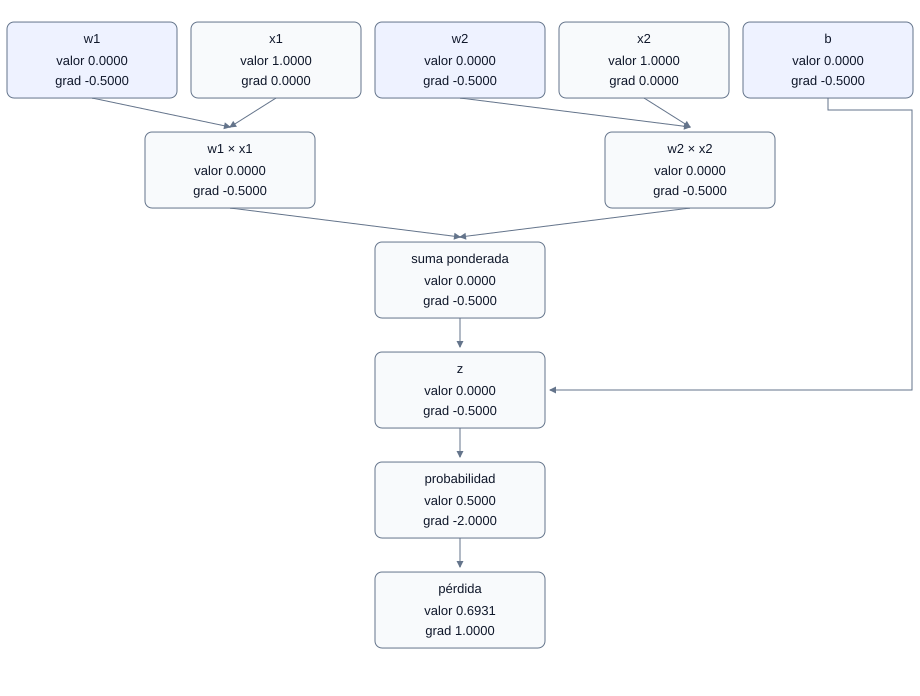

nodo,nombre,operación,valor,gradiente,recibe de
0,w1,hoja,0.000000,-0.500000,sin padres
1,x1,hoja,1.000000,0.000000,sin padres
2,w1 × x1,×,0.000000,-0.500000,"0, 1"
3,w2,hoja,0.000000,-0.500000,sin padres
4,x2,hoja,1.000000,0.000000,sin padres
5,w2 × x2,×,0.000000,-0.500000,"3, 4"
6,suma ponderada,+,0.000000,-0.500000,"2, 5"
7,b,hoja,0.000000,-0.500000,sin padres
8,z,+,0.000000,-0.500000,"6, 7"
9,probabilidad,sigmoide,0.500000,-2.000000,8


In [4]:
dibujar_grafo(L_demo)
nodos_demo = inspeccionar_grafo(L_demo)

La actualización sí cambia los parámetros:

$$\text{nuevo valor}=\text{valor actual}-\eta\times\text{gradiente}.$$

La letra $\eta$ (eta) es la tasa de aprendizaje. Con $\eta=0.1$:
$0-0.1\times(-0.5)=0.05$. **Restar un número negativo aumenta el valor.**
Los tres parámetros pasan a 0.05. Después hay que calcular un forward nuevo.

In [5]:
for parametro in parametros_demo:
    parametro.data = parametro.data - 0.1 * parametro.grad
p_demo_nueva = forward_resuelto(1, 1, parametros_demo)
tabla_parametros(parametros_demo, "Después de actualizar")
print(f"Probabilidad anterior: {p_demo.data:.6f}")
print(f"Probabilidad nueva: {p_demo_nueva.data:.6f}")
print("El objeto de la predicción anterior conserva su valor: necesitamos un forward nuevo.")

parámetro,valor,gradiente
w1,0.050000,-0.500000
w2,0.050000,-0.500000
b,0.050000,-0.500000


Probabilidad anterior: 0.500000
Probabilidad nueva: 0.537430
El objeto de la predicción anterior conserva su valor: necesitamos un forward nuevo.


La nueva probabilidad es aproximadamente **0.537430**, más próxima a 1.
La actualización no borró los gradientes: todavía puedes leerlos.
Reiniciarlos es una operación distinta, que usaremos antes del siguiente backward.

**Punto de pausa:** señala en las salidas un valor que cambió con backward y otro que
solo cambió al actualizar. Si no puedes distinguirlos, revisa estas dos tablas antes de avanzar.

## Etapa 2 · Tu primer forward

Ahora cambia el ejemplo: **(0, 0) con objetivo 0**. La celda de práctica creará parámetros
nuevos en cero; no arrastra los del ejemplo resuelto.

Antes de ejecutar, usa $z=w_1x_1+w_2x_2+b$. Recuerda que multiplicar por cero anula
un producto, pero **el sesgo se suma de todas formas**.

**R2 · Predice antes de ejecutar. Con entradas (0, 0) y parámetros cero, ¿qué probabilidad esperas? Para acercarla al objetivo 0, ¿debería subir o bajar z?**

Predicción del equipo antes de ejecutar: con `x1 = 0` y `x2 = 0`, ambos productos `w1·x1` y `w2·x2` se anulan, así que `z = 0 + 0 + b = 0` porque el sesgo también vale cero. Como sigmoide(0) = 0.5, esperamos probabilidad 0.5 y una pérdida cercana a 0.693147. El objetivo es 0, de modo que la probabilidad debe acercarse a 0: para eso `z` tiene que **bajar** (hacerse negativa), y como las entradas son cero el único parámetro que puede lograrlo es el sesgo `b`.

Completa únicamente las dos líneas con `...`. La función recibe `parametros`, que
contiene los objetos `w1`, `w2`, `b`; ya están separados para ti.

**Contrato:** devolver una probabilidad de tipo `Value`, conservando las conexiones del grafo.
Usa los objetos directamente al construir $z$. `.data` sirve para leer valores o actualizarlos,
pero usarlo aquí rompería las conexiones con los parámetros.

<details><summary>Apoyo si no sabes cómo comenzar</summary>

Python usa `*` para multiplicar y `+` para sumar. Traduce primero la expresión de z.
En la segunda línea llama a `sigmoide` con el objeto que acabas de construir.
No conviertas la probabilidad a 0 o 1 en esta función.

</details>

In [6]:
def predecir(x1, x2, parametros):
    w1, w2, b = parametros
    z = w1 * x1 + w2 * x2 + b   # COMPLETAR: combinación de entradas, pesos y sesgo
    probabilidad = sigmoide(z)  # COMPLETAR: aplicar la sigmoide a z
    if z is Ellipsis or probabilidad is Ellipsis:
        raise ActividadPendiente("Completa las dos líneas de predecir.")
    return probabilidad

In [7]:
estado["forward"] = comprobar_forward(predecir)

FORWARD CORRECTO: valores y conexiones comprobados.


Esta celda está completa. Crea los parámetros de práctica, llama a tu forward y ejecuta
backward para el ejemplo (0, 0). Observa por separado las columnas valor y gradiente.
Cada vez que ejecutes **esta celda completa**, la práctica vuelve a comenzar desde cero.

In [8]:
if estado["forward"]:
    parametros_practica = crear_parametros()
    p_practica = predecir(0, 0, parametros_practica)
    L_practica = perdida_binaria(p_practica, 0)
    print(f"Probabilidad: {p_practica.data:.6f} | Pérdida: {L_practica.data:.6f}")
    valores_antes_practica = valores(parametros_practica)
    L_practica.backward()
    tabla_parametros(parametros_practica, "Práctica (0, 0), después de backward")
    assert valores(parametros_practica) == valores_antes_practica
else:
    print("PENDIENTE: completa y comprueba predecir antes de esta práctica.")

Probabilidad: 0.500000 | Pérdida: 0.693147


parámetro,valor,gradiente
w1,0.000000,0.000000
w2,0.000000,0.000000
b,0.000000,0.500000


**R3 · Contrasta. Anota los tres gradientes observados. ¿Por qué los pesos pueden tener gradiente cero aquí aunque el sesgo no? ¿Backward cambió los valores de los parámetros?**

Gradientes observados tras backward: `w1 = 0.000000`, `w2 = 0.000000`, `b = 0.500000`, con probabilidad 0.500000 y pérdida 0.693147, tal como habíamos previsto en R2.

Los pesos tienen gradiente cero porque la sensibilidad de la pérdida respecto de cada peso queda multiplicada por su entrada, y aquí ambas entradas valen 0: cambiar `w1` o `w2` no modifica `z` en este ejemplo, así que la pérdida no reacciona. El sesgo, en cambio, se suma siempre sin multiplicarse por ninguna entrada, por lo que sí cambia `z` y su gradiente es distinto de cero (0.5, positivo, lo que indica que aumentar `b` aumentaría la pérdida).

Backward **no** cambió los valores: el `assert valores(parametros_practica) == valores_antes_practica` se cumplió y los tres `.data` siguen en 0.0. Backward solo escribe en `.grad`; `.data` y `.grad` son atributos distintos.

## Etapa 3 · Tu primera actualización

Vamos a actualizar los parámetros de la práctica (0, 0), con tasa 0.1.
Usa los gradientes que acabas de observar y la misma regla del ejemplo resuelto.

**R4 · Predice antes de ejecutar. Calcula el nuevo sesgo con tasa 0.1. ¿Qué ocurrirá con ambos pesos y con la probabilidad de la entrada (0, 0)?**

Predicción del equipo antes de ejecutar: aplicando nuevo valor = valor actual − tasa × gradiente, el sesgo pasa a `0 − 0.1 × 0.5 = −0.05`. Los dos pesos **no cambian**, porque su gradiente es 0 y `0 − 0.1 × 0 = 0`; quedan en 0.0. Con `b = −0.05` y entradas nulas, `z = −0.05`, que es negativo, así que la probabilidad debe bajar ligeramente por debajo de 0.5 (esperamos algo cercano a 0.4875) y acercarse al objetivo 0.

Completa la expresión que calcula `nuevo_valor`. El bucle ya está escrito.
`parametro.data` es el valor actual y `parametro.grad` es el gradiente.

**Contrato:** modificar `.data` de los mismos tres objetos. No sustituirlos, no llamar
a backward y no borrar sus gradientes dentro de esta función.

<details><summary>Recordatorio de la regla</summary>

Nuevo valor = valor actual menos tasa por gradiente. `tasa` es un argumento de la función;
no escribas 0.1 de forma fija, porque luego usaremos otra tasa.

</details>

In [9]:
def actualizar(parametros, tasa):
    for parametro in parametros:
        nuevo_valor = parametro.data - tasa * parametro.grad  # COMPLETAR: valor actual menos tasa por gradiente
        if nuevo_valor is Ellipsis:
            raise ActividadPendiente("Completa la expresión de actualizar.")
        parametro.data = nuevo_valor

In [10]:
estado["actualizacion"] = comprobar_actualizacion(actualizar)

ACTUALIZACIÓN CORRECTA: signo, tasa y valores comprobados.


In [11]:
if estado["forward"] and estado["actualizacion"]:
    # Se reconstruye la práctica para que repetir esta celda no añada otro paso.
    parametros_practica = crear_parametros()
    p_practica = predecir(0, 0, parametros_practica)
    L_practica = perdida_binaria(p_practica, 0)
    L_practica.backward()
    actualizar(parametros_practica, 0.1)
    p_practica_nueva = predecir(0, 0, parametros_practica)
    tabla_parametros(parametros_practica, "Práctica después de actualizar")
    print(f"Probabilidad antes: {p_practica.data:.6f} | Después: {p_practica_nueva.data:.6f}")
    reiniciar_gradientes(parametros_practica)
    tabla_parametros(parametros_practica, "Después del reinicio: mismos valores y gradientes en cero")
else:
    print("PENDIENTE: completa primero predecir y actualizar.")

parámetro,valor,gradiente
w1,0.000000,0.000000
w2,0.000000,0.000000
b,-0.050000,0.500000


Probabilidad antes: 0.500000 | Después: 0.487503


parámetro,valor,gradiente
w1,0.000000,0.000000
w2,0.000000,0.000000
b,-0.050000,0.000000


**R5 · Contrasta. ¿Coincidió el resultado con R4? Cita el sesgo y la probabilidad observados. Explica qué conservó y qué cambió reiniciar_gradientes.**

Sí coincidió. El sesgo observado es `b = −0.050000` y los pesos siguen en `w1 = 0.000000` y `w2 = 0.000000`, exactamente como predijimos. La probabilidad pasó de 0.500000 a 0.487503, es decir, bajó por debajo de 0.5 y se acercó al objetivo 0. Nuestra estimación de "cerca de 0.4875" fue correcta.

`reiniciar_gradientes` **conservó los valores** de los tres parámetros: después del reinicio la tabla sigue mostrando `w1 = 0.000000`, `w2 = 0.000000`, `b = −0.050000`. Lo que **cambió** fueron los gradientes almacenados, que pasaron todos a 0.000000. Es decir, borra `.grad` sin tocar `.data`: en cuanto a atributos, es la operación complementaria de backward, que escribe `.grad` sin tocar `.data`.

## Etapa 4 · Integrar el ciclo para los cuatro ejemplos

**Intercambien roles.** Ya completaste el forward y la actualización. Ahora los usarás
dentro de un paso completo, con los cuatro ejemplos de AND a la vez.

`perdida_lote(predecir, parametros)` ya está implementada: calcula cuatro predicciones
usando los **mismos tres objetos parámetro** y obtiene la media de sus pérdidas.
No hay doce parámetros independientes. Al hacer backward, el motor reúne en cada parámetro
las contribuciones de los cuatro ejemplos, con el factor de la media.

$$L=\frac{L_{00}+L_{01}+L_{10}+L_{11}}{4}.$$

Cada iteración usa esta secuencia:

| Orden | Operación | Responsabilidad |
|---:|---|---|
| 1 | `reiniciar_gradientes(parametros)` | Quitar contribuciones de iteraciones anteriores |
| 2 | `perdida_lote(predecir, parametros)` | Forward nuevo y pérdida media escalar |
| 3 | `L.backward()` | Calcular gradientes de esa pérdida |
| 4 | `actualizar(parametros, tasa)` | Cambiar los valores usando esos gradientes |

Las contribuciones de los cuatro ejemplos **sí se reúnen** dentro de un paso.
Reiniciamos entre pasos porque queremos el gradiente de la pérdida actual.
El motor de este paquete reinicia con ceros; no utiliza el estado `None` de PyTorch.

**R6 · Antes de completar el ciclo. ¿Por qué actualizar debe ir después de backward? ¿Qué información conservaríamos por error entre iteraciones si no reiniciáramos los gradientes?**

`actualizar` debe ir después de `backward` porque la regla nuevo valor = valor actual − tasa × gradiente necesita que `.grad` ya contenga el gradiente de la pérdida actual. Antes de backward los gradientes están en cero (recién reiniciados) o corresponden a otra pérdida; si actualizáramos primero, restaríamos cero —y nada cambiaría— o aplicaríamos una dirección calculada para parámetros que ya no son los vigentes. Además, backward exige un grafo nuevo, y el forward que lo construye ocurre antes de la actualización.

Si no reiniciáramos, el motor usa `+=` para reunir contribuciones, así que los gradientes de la iteración anterior seguirían sumados a los de la actual. Acumularíamos una suma de gradientes de pérdidas ya superadas, calculados sobre valores de parámetros antiguos. El paso sería cada vez más grande y apuntaría a una mezcla de direcciones históricas en lugar de a la dirección de la pérdida actual. Dentro de un mismo paso sí queremos que se reúnan las contribuciones de los cuatro ejemplos del lote; lo que no queremos es que se mezclen entre iteraciones distintas.

Completa cuatro lugares usando la tabla anterior. La función debe devolver `L`, la pérdida
calculada **antes** de la actualización. No escribas el bucle de 600 iteraciones:
el controlador proporcionado lo hará llamando a tu función.

<details><summary>Cómo usar funciones que ya están disponibles</summary>

Una llamada a una función que modifica parámetros puede ocupar una línea sola.
Una función que produce un resultado se asigna a una variable: `L = nombre(argumentos)`.
Backward es un método del objeto pérdida: se escribe con un punto.

</details>

In [12]:
def paso_entrenamiento(parametros, tasa):
    reiniciar_gradientes(parametros)        # COMPLETAR 1: reiniciar gradientes
    L = perdida_lote(predecir, parametros)  # COMPLETAR 2: calcular la pérdida del lote
    if L is Ellipsis:
        raise ActividadPendiente("Completa las cuatro operaciones del paso.")
    L.backward()                 # COMPLETAR 3: ejecutar backward sobre L
    actualizar(parametros, tasa)  # COMPLETAR 4: actualizar los parámetros con la tasa recibida
    return L

In [13]:
if estado["forward"] and estado["actualizacion"]:
    estado["ciclo"] = comprobar_paso(paso_entrenamiento, predecir, actualizar)
else:
    print("PENDIENTE: el ciclo necesita predecir y actualizar completos.")

CICLO CORRECTO: reinicio, forward, pérdida, backward y actualización.


### Ejecutar el entrenamiento

Usaremos inicialización en cero, **600 pasos y tasa 0.5**. No hay aleatoriedad ni semilla
que ajustar. La celda crea parámetros nuevos para repetir el experimento desde el mismo estado.

La tabla registra `loss_antes` (pérdida antes de actualizar), `grad_norm` (tamaño conjunto
de los tres gradientes) y `change_norm` (tamaño conjunto del cambio de parámetros).
También conserva cada valor antes y después. Las normas las calcula el apoyo proporcionado;
no tienes que programarlas ni derivarlas.

En la gráfica de parámetros, las curvas de `w1` y `w2` coinciden en este experimento:
una línea continua y otra discontinua permiten reconocer la superposición. No falta un peso.

**No confundas el primer paso de este lote con el ejemplo resuelto (1, 1):** ahora
participan cuatro objetivos. Por eso los gradientes iniciales pueden ser diferentes.

paso,loss_antes,grad_w1,grad_w2,grad_b,w1_despues,w2_despues,b_despues
1,0.693147,0.000000,0.000000,0.250000,0.000000,0.000000,-0.125000
2,0.663849,-0.015605,-0.015605,0.218791,0.007802,0.007802,-0.234395
3,0.640956,-0.027722,-0.027722,0.193593,0.021663,0.021663,-0.331192


paso,loss_antes,grad_norm,change_norm
1,0.693147,0.250000,0.125000
100,0.229029,0.052414,0.026207
300,0.104354,0.023975,0.011988
600,0.056537,0.013251,0.006625


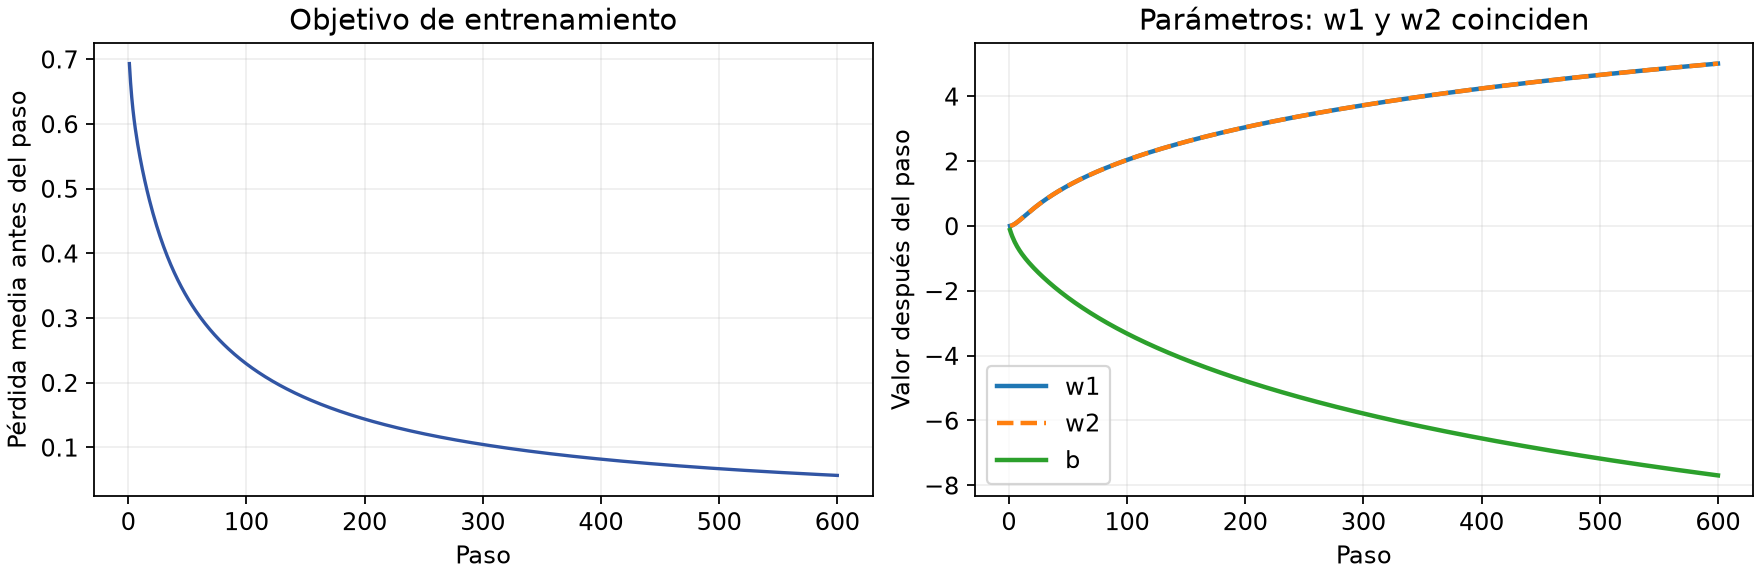

In [14]:
historial = []
parametros_entrenados = None
if all(estado.values()):
    parametros_entrenados = crear_parametros()
    tabla_inicial = evaluar(predecir, parametros_entrenados)
    historial = entrenar(paso_entrenamiento, predecir, parametros_entrenados)
    tabla_final = evaluar(predecir, parametros_entrenados)
    tabla([{k: row[k] for k in ("paso", "loss_antes", "grad_w1", "grad_w2", "grad_b", "w1_despues", "w2_despues", "b_despues")} for row in historial[:3]], "Primeros tres pasos del lote")
    tabla([{k: row[k] for k in ("paso", "loss_antes", "grad_norm", "change_norm")} for row in (historial[0], historial[99], historial[299], historial[-1])], "Registro de cuatro momentos")
    guardar_resultados(historial, tabla_final, OUTPUT_DIR)
else:
    print("PENDIENTE: completa las tres funciones. No se ha entrenado un modelo sustituto.")

**R7 · Lee el registro. ¿Qué parámetros cambiaron en el primer paso del lote? ¿Los pesos permanecieron iguales también en el segundo? Cita valores de la tabla, sin derivar la pérdida.**

En el primer paso del lote solo cambió el sesgo. La tabla registra `loss_antes = 0.693147` con gradientes `grad_w1 = 0.000000`, `grad_w2 = 0.000000` y `grad_b = 0.250000`; los valores después son `w1_despues = 0.000000`, `w2_despues = 0.000000` y `b_despues = −0.125000`, que es `0 − 0.5 × 0.25`. Los pesos tienen gradiente nulo en este primer paso porque, partiendo de los tres parámetros en cero, las cuatro probabilidades valen 0.5 y las contribuciones de los ejemplos con entrada 1 se cancelan entre sí.

En el **segundo paso los pesos ya no permanecen iguales**. La tabla muestra `loss_antes = 0.663849`, `grad_w1 = grad_w2 = −0.015605` y `grad_b = 0.218791`, con valores después `w1_despues = w2_despues = 0.007802` y `b_despues = −0.234395`. Al haber cambiado el sesgo en el paso anterior, las cuatro probabilidades ya no son iguales y la cancelación desaparece. Nótese también que `w1` y `w2` toman siempre el mismo valor: la tabla AND es simétrica en ambas entradas y ambos parten de cero, por lo que sus curvas se superponen en la gráfica.

## Etapa 5 · Comprobar si aprendió AND

Una curva descendente no reemplaza la tabla de verdad. Compara las predicciones iniciales
y finales sobre las cuatro entradas. La columna `clase` aplica el umbral 0.5 **solo aquí**.
La siguiente celda no llama a backward ni actualiza parámetros.

In [15]:
if parametros_entrenados is not None:
    valores_antes_eval = valores(parametros_entrenados)
    grads_antes_eval = gradientes(parametros_entrenados)
    tabla_final = evaluar(predecir, parametros_entrenados)
    tabla(tabla_inicial, "Antes del entrenamiento")
    tabla(tabla_final, "Después del entrenamiento")
    perdida_final = perdida_lote(predecir, parametros_entrenados).data
    print(f"Pérdida inicial: {historial[0]['loss_antes']:.6f}")
    print(f"Pérdida tras la última actualización: {perdida_final:.6f}")
    print(f"Aciertos: {sum(row['correcta'] for row in tabla_final)} de 4")
    assert valores(parametros_entrenados) == valores_antes_eval
    assert gradientes(parametros_entrenados) == grads_antes_eval
    print("Evaluar conservó los valores de los parámetros y los gradientes almacenados.")
else:
    print("PENDIENTE: primero completa el entrenamiento.")

x1,x2,objetivo,probabilidad,clase,correcta
0,0,0,0.500000,1,False
0,1,0,0.500000,1,False
1,0,0,0.500000,1,False
1,1,1,0.500000,1,True


x1,x2,objetivo,probabilidad,clase,correcta
0,0,0,0.000454,0,True
0,1,0,0.063700,0,True
1,0,0,0.063700,0,True
1,1,1,0.910552,1,True


Pérdida inicial: 0.693147
Pérdida tras la última actualización: 0.056449
Aciertos: 4 de 4
Evaluar conservó los valores de los parámetros y los gradientes almacenados.


### Cómo interpretar el resultado

Aprender esta tabla no exige probabilidades exactamente 0 y 1 ni pérdida cero.
Para la actividad pedimos las cuatro clases correctas y pérdida final menor que la inicial,
con la configuración proporcionada. No se buscan pesos específicos.

Un sistema que respondiera siempre cero acertaría **3 de 4 casos, es decir, 75%**.
Sin embargo, fallaría justamente cuando ambos permisos están presentes.
El modelo inicial de este notebook no es ese sistema constante: con probabilidad 0.5
y la regla `>= 0.5`, comienza respondiendo 1 para las cuatro entradas.

Aquí comprobamos todas las entradas binarias posibles de AND, usadas también al entrenar.
**No es una estimación de generalización a datos nuevos.** Tampoco podemos concluir que
una neurona resuelva cualquier otra regla lógica.

Este motor educativo no tiene `model.train()`, `model.eval()` ni `torch.no_grad()`.
Su evaluación todavía construye un grafo, pero no hace backward ni actualiza.
No debe confundirse con un contexto sin registro de gradientes de PyTorch.

**R8 · Conclusión del equipo. Cita las cuatro probabilidades finales y la pérdida inicial/final. ¿Implementa AND al aplicar el umbral? Explica por qué 75% no bastaría y qué conservó la evaluación.**

Probabilidades finales tras los 600 pasos con tasa 0.5: (0, 0) → 0.000454; (0, 1) → 0.063700; (1, 0) → 0.063700; (1, 1) → 0.910552. La pérdida inicial fue 0.693147 y la pérdida tras la última actualización 0.056449, claramente menor. Los aciertos son 4 de 4.

Sí implementa AND con el umbral 0.5: las tres primeras probabilidades están por debajo de 0.5 y dan clase 0, y la última está por encima y da clase 1, que es exactamente la tabla de verdad de AND. Las probabilidades no son 0 y 1 exactos, y no hace falta que lo sean: lo que se pide es la clase correcta en los cuatro casos y una pérdida final menor que la inicial.

Un 75% no bastaría porque ese es justamente el acierto de un sistema que respondiera siempre 0: acertaría (0, 0), (0, 1) y (1, 0) y fallaría (1, 1), es decir, fallaría precisamente el único caso que el dispositivo debe detectar. La métrica global escondería el error en la clase que importa, con clases desbalanceadas 3 a 1. Nuestro modelo inicial tampoco era ese sistema constante: con probabilidad 0.5 en las cuatro entradas y la regla `>= 0.5`, empezó respondiendo 1 a todo, acertando solo 1 de 4.

La evaluación **conservó** tanto los valores de los parámetros como los gradientes almacenados: los dos `assert` de la celda se cumplieron. `evaluar` hace un forward nuevo, y por tanto construye grafo, pero no llama a backward ni actualiza nada. Conviene advertir el límite: aquí comprobamos las cuatro entradas binarias posibles, que son las mismas con las que entrenamos, así que esto no es una estimación de generalización a datos nuevos ni permite concluir que una sola neurona resuelva cualquier otra regla lógica.

### Explicación individual breve

Cada integrante escribe dos o tres frases con sus propias palabras. Puede consultar sus
resultados, pero no repetir literalmente la respuesta de su compañero. Si el docente
autorizó trabajo individual, escribe “Trabajo individual autorizado” en el segundo espacio.

**Integrante 1 · Explica la diferencia entre calcular un gradiente y actualizar un parámetro. Usa un número del ejemplo o de tu práctica.**

Calcular un gradiente es medir; actualizar es mover. En nuestra práctica con (0, 0), backward dejó `b.grad = 0.5` pero el valor del sesgo siguió siendo 0.0: el gradiente solo dice en qué dirección y con qué intensidad reacciona la pérdida si movemos ese parámetro, y se escribe en `.grad`. Recién al actualizar con tasa 0.1 el valor pasó a `−0.05`, que sale de `0 − 0.1 × 0.5`, y eso se escribe en `.data`. Son dos atributos distintos del mismo objeto, y por eso backward puede ejecutarse sin que ningún parámetro se mueva.

**Integrante 2 · ¿Qué es lo primero que mirarías si los valores de los parámetros no cambian? Usa .grad, la tasa y la tabla antes/después en tu explicación.**

Lo primero que miraría es `.grad`: si vale 0.0, restar tasa × gradiente deja el valor idéntico, sin importar la tasa. Eso fue justo lo que les pasó a `w1` y `w2` en nuestra práctica (0, 0), donde ambos gradientes fueron 0.000000 y sus valores siguieron en 0.0 después de actualizar. Si los gradientes no son cero, entonces revisaría la tasa, porque una tasa muy pequeña produce un cambio inapreciable, y el orden del ciclo: que backward se ejecute antes de actualizar y que no se hayan reiniciado los gradientes en medio. La tabla antes/después es la evidencia que separa los dos casos, porque muestra en la misma fila el valor previo, el gradiente y el valor posterior.

## Etapa 6 · Verificar y entregar

Esta comprobación automática revisa código y resultados numéricos. **No califica la
calidad de tus explicaciones ni demuestra que escribiste las predicciones antes de ejecutar.**
Las respuestas serán revisadas por el docente.

In [16]:
validacion_tecnica = False
if all(estado.values()) and parametros_entrenados is not None:
    validacion_tecnica = validar_final(predecir, actualizar, paso_entrenamiento, historial, parametros_entrenados)
    print("COMPROBACIONES NUMÉRICAS CORRECTAS. Falta revisar y guardar las respuestas escritas.")
else:
    print("ACTIVIDAD INCOMPLETA: revisa los mensajes PENDIENTE y completa las tres funciones.")

COMPROBACIONES NUMÉRICAS CORRECTAS. Falta revisar y guardar las respuestas escritas.


1. Completa los nombres y todas las respuestas; elimina sus marcadores de edición.
2. Usa **Kernel → Restart Kernel and Run All Cells** y guarda el notebook.
3. Desde una terminal, en la carpeta `hackathon3_student`, ejecuta:

```bash
uv run python verify_notebook.py
```

El verificador vuelve a ejecutar una copia con un kernel limpio del mismo entorno y crea
`output/verificacion/Hackathon_3_Verificado.ipynb`. Un resultado correcto termina con
**VERIFICACIÓN TÉCNICA COMPLETA**. El original no se sobrescribe.

Entrega un ZIP con `Hackathon_3_Starter.ipynb` guardado y la carpeta `output/`.
No incluyas `.venv/`, cachés ni archivos del docente. Si alguna etapa queda pendiente,
conserva tus respuestas y resultados parciales; no inventes evidencia para obtener el mensaje final.

## Criterios de evaluación

| Criterio | Peso |
|---|---:|
| Reconocer el problema y completar el forward | 15% |
| Predicciones razonadas antes de ejecutar | 20% |
| Interpretar gradientes y completar la actualización | 20% |
| Completar el ciclo y leer su registro | 20% |
| Explicar la tabla final y sus límites | 15% |
| Reproducibilidad y explicación individual | 10% |

Una predicción razonada que luego corriges con evidencia puede recibir crédito completo.
No se evalúa derivar la sigmoide o BCE ni implementar el motor.

## Referencias y procedencia

La actividad y el motor escalar fueron escritos para este curso. Los datos son la tabla
de verdad AND, no un conjunto externo. La regla de actualización y la lectura causal del
ciclo continúan el material M08. Sigmoide y pérdida binaria se entregan como apoyos.
No necesitas abrir referencias externas durante el hackathon.